# Loss Functions

This is more or less how well your model is performing.

**Least squares** e.g. used by Linear Regression
**0-1** often used for conceptual understanding

In [1]:
from scipy.optimize import minimize
import numpy as np

minimize(np.square, 0).x

array([0.])

In [2]:
minimize(np.square, 2).x

array([-1.88846401e-08])

In [3]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
X, y = dataset.data, dataset.target

In [4]:
def sample_loss_function(w):
    s = 0
    for i in range(y.size):
        # Get the actual and predicted values for 'i'
        y_i_true = y[i]
        y_i_pred = w@X[i]
        # The error for this example is the squared distance between the true and predicted target values
        s = s + (y_i_true - y_i_pred)**2
    return s

# Returns the w that minimizes the loss function
w_fit = minimize(sample_loss_function, X[0]).x
print(w_fit)

[-4.41371475e+03  9.94765912e+02  2.08994963e+03 -6.30873865e+01
  3.03885388e+05 -8.41801037e+04  6.48718693e+04 -3.94949460e+05
 -6.86096003e+04  7.77542489e+05  1.27423830e+04  4.24914750e+03
  8.37806325e+03 -3.50476704e+02 -7.21144352e+04  4.58903228e+05
  3.94721789e+05 -4.01183425e+06 -4.53937166e+05 -5.88635652e+05
 -2.55401071e+03 -9.18743336e+02 -1.02393035e+03  5.30099502e+01
 -1.63960284e+05 -9.29405766e+03 -5.70248580e+04  5.36880118e+05
  2.67932830e+04 -4.47043889e+05]


In [5]:
# Compare with coefficients from sklearn's LinearRegression
from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=False).fit(X, y)
print(lr.coef_)

[ 4.20048238e-01 -2.62153812e-03 -2.39140928e-02 -1.85607593e-03
 -3.50641263e-01  1.22436738e-01 -8.50448171e-01 -3.46627071e+00
  7.00710101e-01  2.78415772e+01 -3.76296067e-01 -2.11018810e-03
  7.14847109e-03  2.13960183e-03 -1.38783330e+01  2.77953618e+00
  3.48764215e+00 -1.08563318e+01 -1.30046054e+00 -1.53194185e+01
 -2.52665298e-01 -5.85892581e-03  6.89389150e-03  1.18172626e-03
  3.72669307e-01  1.49020705e-01 -4.66897919e-01 -5.76613586e-01
 -6.78151632e-01 -5.85613887e+00]


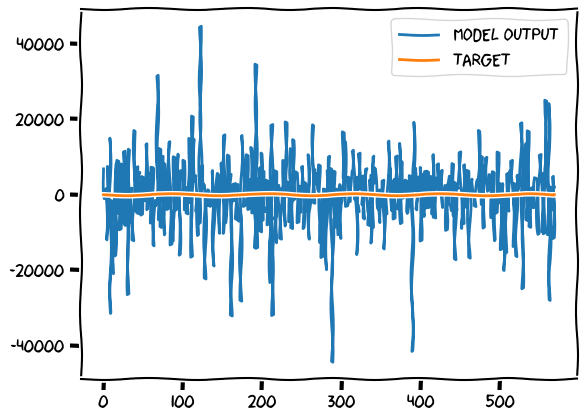

In [6]:
# Plot the raw model output
import matplotlib.pyplot as plt
plt.xkcd()

plt.plot(X@w_fit, label='model output')
plt.plot(y, label='target')
plt.legend()
plt.show()

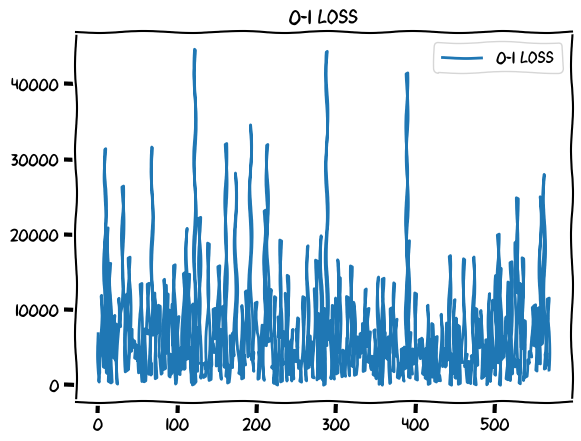

In [7]:
# Plot a 0-1 loss function

def zero_one_loss(y_true, y_pred):
    return np.abs(y_true - y_pred)

# Plot a hinge loss function
plt.title('0-1 loss')
plt.plot(zero_one_loss(y, X@w_fit), label='0-1 loss')
plt.legend()
plt.show()

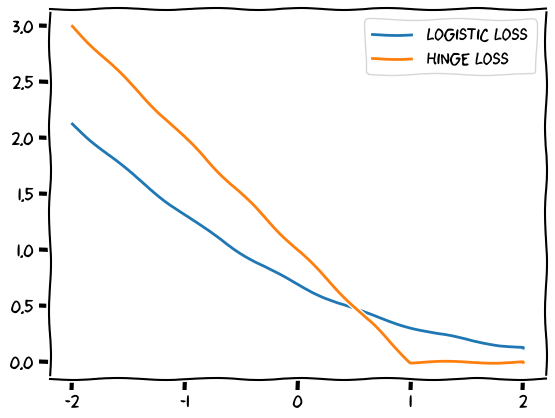

In [8]:
# Compare the logistic and hinge loss functions

def logistic_loss(y_true, y_pred):
    return np.log(1 + np.exp(-y_true * y_pred))

def hinge_loss(y_true, y_pred):
    return np.maximum(0, 1 - y_true * y_pred)

grid = np.linspace(-2, 2, 1000) # raw model output
plt.plot(grid, logistic_loss(1, grid), label='logistic loss')
plt.plot(grid, hinge_loss(1, grid), label='hinge loss')
plt.legend()
plt.show()

In [9]:
from sklearn.linear_model import LogisticRegression

# loss function for logistic regression
def logistic_regression_loss(w):
    s = 0
    for i in range(y.size):
        raw_model_output = w@X[i]
        s = s + np.log(1 + np.exp(-y[i] * raw_model_output))
    return s

w_fit = minimize(logistic_regression_loss, X[0]).x
print(w_fit)

# Compare with scikit-learn's LogisticRegression
# A large C means a more complex (less regularized) model
lr = LogisticRegression(fit_intercept=False, C=1000000).fit(X,y)
print(lr.coef_)

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
[[ 1.09295172  0.5174376   0.25718884 -0.01646842 -0.04141286 -0.19363619
  -0.27092381 -0.11424677 -0.05733489 -0.01149258  0.04794705  0.43786607
   0.18116544 -0.1320146  -0.0037214  -0.04141833 -0.05776434 -0.01483482
  -0.01384323 -0.00385649  1.16221356 -0.57970063 -0.24812647 -0.01481967
  -0.07491997 -0.60247886 -0.74986707 -0.21951705 -0.18121112 -0.05810375]]


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
